Using cache found in C:\Users\sahar/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\sahar\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sahar\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



0: 448x640 3 cups, 145.4ms
Speed: 36.5ms preprocess, 145.4ms inference, 2.3ms postprocess per image at shape (1, 3, 448, 640)
YOLO พบ 3 candidate boxes
  box 0: class='cup' conf=0.59  ← ชื่อ class ไม่สำคัญ!
  box 1: class='cup' conf=0.18  ← ชื่อ class ไม่สำคัญ!
  box 2: class='cup' conf=0.12  ← ชื่อ class ไม่สำคัญ!

COUNT = 3


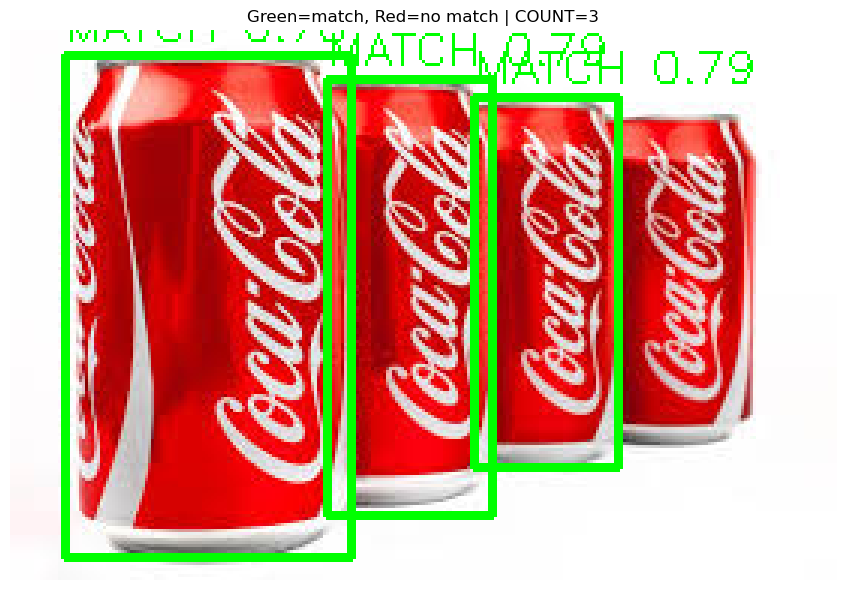

In [1]:
from ultralytics import YOLO
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

# ── Encoder ───────────────────────────────────────────────────────────────────
encoder = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
encoder = torch.nn.Sequential(*list(encoder.children())[:-1])
encoder.eval()

def encode(img):
    img = cv2.resize(img, (224, 224)) / 255.0
    img = np.transpose(img, (2, 0, 1))
    x = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        feat = encoder(x).squeeze().numpy()
    return feat / np.linalg.norm(feat)

# ── Build Prototype ───────────────────────────────────────────────────────────
reference_images = ['coke-can.png']   # ← ใส่รูป reference อะไหล่ของคุณที่นี่
ref_embeddings = [encode(cv2.imread(p)) for p in reference_images]
prototype = np.mean(ref_embeddings, axis=0)
prototype /= np.linalg.norm(prototype)

# ── Detect with YOLO ──────────────────────────────────────────────────────────
#
# KEY POINT: เราไม่สนว่า YOLO จะเรียกมันว่าอะไร
# เราแค่ต้องการ "bounding boxes" ของ object ทุกชิ้นในภาพ
#
# conf=0.1  → จับทุกอย่างที่ดูเหมือน object แม้ confidence ต่ำ
# classes=None → ไม่กรอง class (รับทุก class)
# iou=0.3   → ลด overlap ของ boxes
#
yolo = YOLO('yolov8n.pt')
scene = cv2.imread('./coke-cans.jpg')

results = yolo(scene, conf=0.1, iou=0.3)[0]  # ← conf ต่ำ = จับได้มากขึ้น

print(f"YOLO พบ {len(results.boxes)} candidate boxes")
for i, box in enumerate(results.boxes.xyxy):
    cls_id = int(results.boxes.cls[i].item())
    conf   = float(results.boxes.conf[i].item())
    print(f"  box {i}: class='{yolo.names[cls_id]}' conf={conf:.2f}  ← ชื่อ class ไม่สำคัญ!")

# ── Match กับ Prototype ───────────────────────────────────────────────────────
count = 0
threshold = 0.75  # ปรับค่านี้: สูง = strict, ต่ำ = หลวม

output = scene.copy()
for i, box in enumerate(results.boxes.xyxy):
    x1, y1, x2, y2 = map(int, box.tolist())
    crop = scene[y1:y2, x1:x2]
    if crop.size == 0:
        continue

    sim = float(np.dot(encode(crop), prototype))  # cosine similarity
    matched = sim > threshold

    color = (0, 255, 0) if matched else (0, 0, 255)  # เขียว=ใช่, แดง=ไม่ใช่
    cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)
    label = f"MATCH {sim:.2f}" if matched else f"skip {sim:.2f}"
    cv2.putText(output, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    if matched:
        count += 1

print(f"\nCOUNT = {count}")
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"Green=match, Red=no match | COUNT={count}")
plt.axis("off")
plt.tight_layout()
plt.savefig("result.png", dpi=150)
plt.show()